In [ ]:
! pip install astroNN

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 46.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 51.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.7 MB/s eta 0:00:0000:01


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical, array_to_img # type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from tensorflow.keras.models import Model # type: ignore
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization, Dropout, GlobalAveragePooling2D, Conv2D # type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # type: ignore
from tensorflow.keras.preprocessing.image import * # type: ignore
from tensorflow.keras.optimizers import Adam # type: ignore
import random
from collections import Counter
import cv2
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from astroNN.datasets import load_galaxy10
from PIL import Image
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="keras.src.trainers.data_adapters.py_dataset_adapter")

2025-07-15 21:14:01.760214: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752614041.943190    1059 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752614041.997131    1059 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# 1. Load Data

In [ ]:
# Function for loading
def load_and_preprocess_data():
    # Sostituisci con la tua funzione di caricamento
    images, labels = load_galaxy10()
    return images, labels

In [ ]:
# Class name that corresponds to the labels
class_names = [
    "Disturbed", "Merging", "Round Smooth", "In-between Round Smooth", "Cigar-shaped Smooth",
    "Barred Spiral", "Unbarred Spiral", "Edge-on w/ Bulge", "Edge-on w/o Bulge", "Irregular"
]

# Loanding and one-hot encoding
images, labels = load_and_preprocess_data()
labels_onehot = to_categorical(labels, num_classes=10)

/root/.astroNN/datasets/Galaxy10_DECals.h5 was found!


# 2. Sampling of the original dataset

In [ ]:
# Use of a % to be fast
sample_frac = 0.50
num_samples = int(len(images) * sample_frac)
indices = np.random.choice(len(images), num_samples, replace=False)
images = images[indices]
labels = labels[indices]
labels_onehot = labels_onehot[indices]


# 3. Preprocessing

In [ ]:
# Resize
images = tf.image.resize(images, [128, 128])

I0000 00:00:1752614152.752697    1059 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1752614152.753335    1059 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
# Display dataset information
print(f"Number of images: {len(images)}")
print(f"Shape of each image: {images[0].shape}")
unique_labels = np.unique(labels)
print(f"Unique labels: {unique_labels}")

#
print(f"Shape of labels_onehot: {labels_onehot.shape}")

#
for i, class_name in enumerate(class_names):
    print(f"Class {i}: {class_name}")

Number of images: 8868
Shape of each image: (128, 128, 3)
Unique labels: [0 1 2 3 4 5 6 7 8 9]
Shape of labels_onehot: (8868, 10)
Class 0: Disturbed
Class 1: Merging
Class 2: Round Smooth
Class 3: In-between Round Smooth
Class 4: Cigar-shaped Smooth
Class 5: Barred Spiral
Class 6: Unbarred Spiral
Class 7: Edge-on w/ Bulge
Class 8: Edge-on w/o Bulge
Class 9: Irregular


In [ ]:
# Train, val, test
images_np = images.numpy() if hasattr(images, "numpy") else images
labels_onehot_np = labels_onehot.numpy() if hasattr(labels_onehot, "numpy") else labels_onehot

X_train, X_temp, y_train, y_temp = train_test_split(
    images_np, labels_onehot_np, train_size=0.7, random_state=42, shuffle=True, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True, stratify=np.argmax(y_temp, axis=1)
)

# Normalization
X_train_norm = X_train.astype('float32') / 255.0
X_val_norm = X_val.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# Mean e std on normalized data
means = X_train_norm.mean(axis=(0, 1, 2))
stds = X_train_norm.std(axis=(0, 1, 2)) + 1e-7

# Standardization
def standardize_img(img):
    return (img - means) / stds

# Application of the function
X_train_norm_std = standardize_img(X_train_norm)
X_val_norm_std = standardize_img(X_val_norm)
X_test_norm_std = standardize_img(X_test_norm)

# Data augmentation
y_train_labels = np.argmax(y_train, axis=1)
counts = Counter(y_train_labels)
minority_class = min(counts, key=counts.get)

minority_idxs = np.where(y_train_labels == minority_class)[0]
X_minority = X_train_norm_std[minority_idxs]
y_minority = y_train[minority_idxs]

aug = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

target_count = int(np.mean([v for k, v in counts.items() if k != minority_class]))
n_needed = target_count - len(X_minority)
n_per_image = max(1, int(np.ceil(n_needed / len(X_minority))))

X_aug, y_aug = [], []
for img, label in zip(X_minority, y_minority):
    img_exp = np.expand_dims(img, axis=0)
    aug_iter = aug.flow(img_exp, np.expand_dims(label, axis=0), batch_size=1)
    for _ in range(n_per_image):
        aug_img, aug_label = next(aug_iter)
        X_aug.append(aug_img[0])
        y_aug.append(aug_label[0])
        if len(X_aug) + len(X_minority) >= target_count:
            break
    if len(X_aug) + len(X_minority) >= target_count:
        break

# Concat of original data with augmewnted
X_train_balanced = np.concatenate([X_train_norm_std, np.array(X_aug)], axis=0)
y_train_balanced = np.concatenate([y_train, np.array(y_aug)], axis=0)

# Batch-friendly
batch_size = 32
train_gen = ImageDataGenerator()  # nessuna preprocessing_function, già preprocessati
val_gen = ImageDataGenerator()
test_gen = ImageDataGenerator()

train_flow = train_gen.flow(X_train_balanced, y_train_balanced, batch_size=batch_size, shuffle=True)
val_flow = val_gen.flow(X_val_norm_std, y_val, batch_size=batch_size, shuffle=False)
test_flow = test_gen.flow(X_test_norm_std, y_test, batch_size=batch_size, shuffle=False)

# 4. Distribution of the classes before and after data augmentation

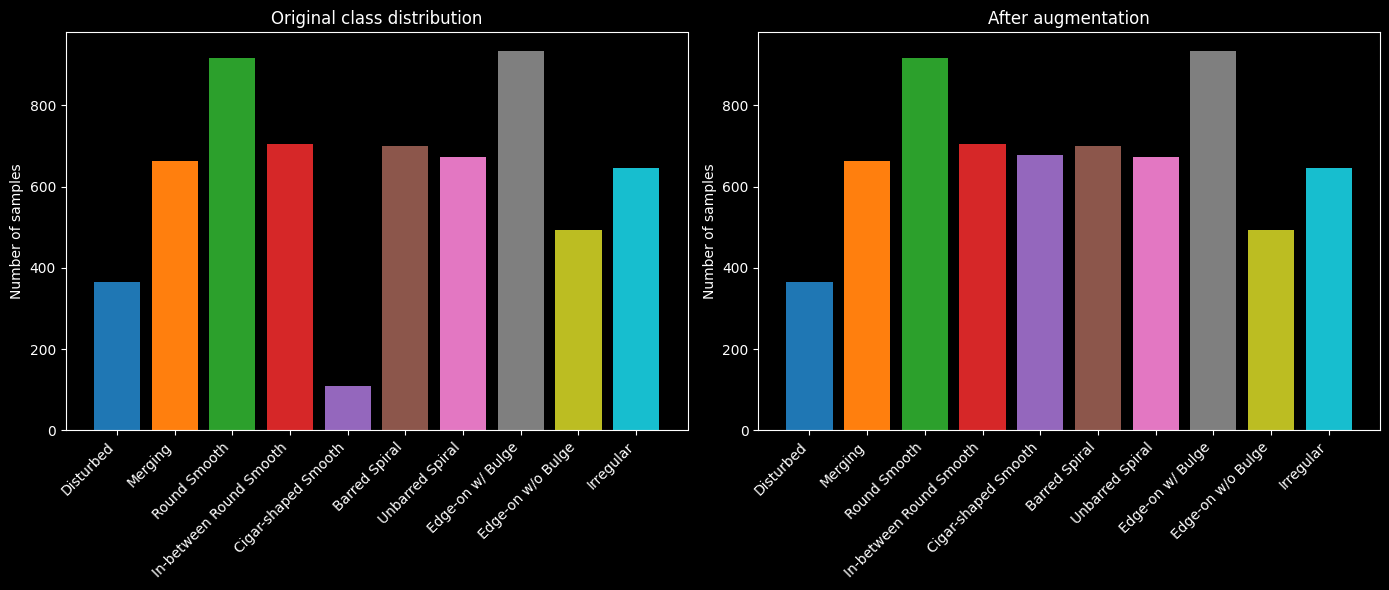

In [ ]:
# Calcola la distribuzione delle classi prima e dopo l'augmentation
num_classes = len(class_names)
original_counts = np.bincount(y_train_labels, minlength=num_classes)
balanced_counts_list = np.bincount(np.argmax(y_train_balanced, axis=1), minlength=num_classes)

plt.style.use('dark_background')  # Sfondo nero

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafico originale
axes[0].bar(np.arange(num_classes), original_counts, color=plt.get_cmap('tab10').colors)
axes[0].set_xticks(np.arange(num_classes))
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].set_ylabel('Number of samples')
axes[0].set_title('Original class distribution')

# Grafico dopo augmentation
axes[1].bar(np.arange(num_classes), balanced_counts_list, color=plt.get_cmap('tab10').colors)
axes[1].set_xticks(np.arange(num_classes))
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].set_ylabel('Number of samples')
axes[1].set_title('After augmentation')

plt.tight_layout()
plt.show()

# 5. Employment of the Deep Learning Models

## 5.1 VGG16

In [ ]:
from tensorflow.keras.applications import VGG16 #type: ignore

num_classes = len(class_names)
img_height = images.shape[1]
img_width = images.shape[2]

# Backbone VGG16 pre-trained
vgg = VGG16(
    input_shape=(img_height, img_width, 3),
    weights='imagenet',
    include_top=False
)
for layer in vgg.layers:
    layer.trainable = False

# Head personalizzato
x = GlobalAveragePooling2D()(vgg.output)
x = Dense(num_classes, activation='softmax')(x)
model_VGG16 = Model(inputs=vgg.input, outputs=x)

model_VGG16.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)


In [ ]:
model_VGG16.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,730,080 (56.19 MB)

 Trainable params: 5,130 (20.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 10,262 (40.09 KB)

In [ ]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_VGG16.keras', save_best_only=True)
]

# Train with generatori
history_VGG16 = model_VGG16.fit(
    train_flow,
    epochs=15,
    validation_data=val_flow,
    callbacks=callbacks
)

Epoch 1/15


I0000 00:00:1752614292.315399    1094 service.cc:148] XLA service 0x780b40006490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752614292.316036    1094 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1752614292.316074    1094 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1752614292.638908    1094 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/212 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.1163 - loss: 2.4847

I0000 00:00:1752614299.844986    1094 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


212/212 ━━━━━━━━━━━━━━━━━━━━ 37s 131ms/step - accuracy: 0.2644 - loss: 2.0839 - val_accuracy: 0.3774 - val_loss: 1.8099
Epoch 2/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - accuracy: 0.4564 - loss: 1.6271 - val_accuracy: 0.4308 - val_loss: 1.6507
Epoch 3/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - accuracy: 0.5042 - loss: 1.4779 - val_accuracy: 0.4556 - val_loss: 1.5814
Epoch 4/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.5398 - loss: 1.3787 - val_accuracy: 0.4752 - val_loss: 1.5248
Epoch 5/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.5362 - loss: 1.3584 - val_accuracy: 0.4887 - val_loss: 1.4871
Epoch 6/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.5484 - loss: 1.3209 - val_accuracy: 0.4962 - val_loss: 1.4607
Epoch 7/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 17s 80ms/step - accuracy: 0.5676 - loss: 1.2825 - val_accuracy: 0.4947 - val_loss: 1.4391
Epoch 8/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 17s 80ms/step - accuracy: 0.5585 - loss: 1.2817 - val_accura

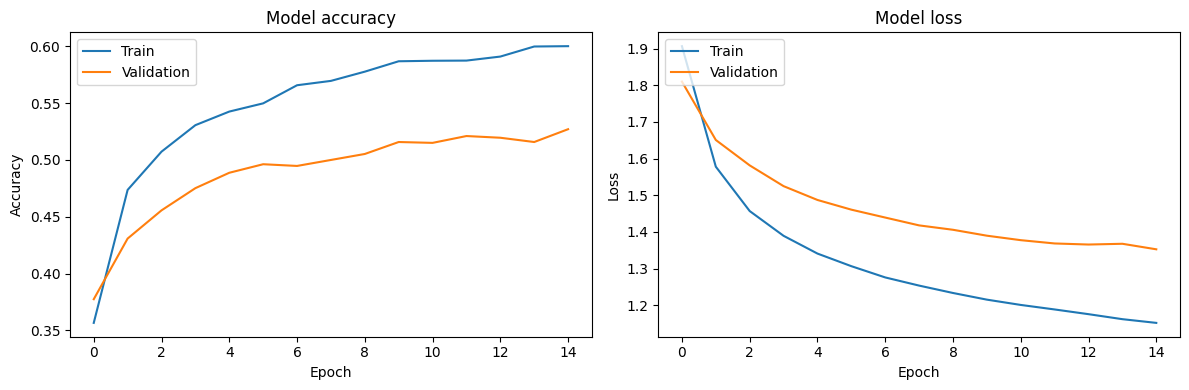

In [ ]:
# Plot accuracy and loss over epochs
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_VGG16.history['accuracy'])
plt.plot(history_VGG16.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_VGG16.history['loss'])
plt.plot(history_VGG16.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.metrics import CategoricalAccuracy

# Evaluate the model on the test set
test_loss_VGG16, test_acc_VGG16 = model_VGG16.evaluate(test_flow, verbose=0)
print(f'Test Accuracy: {test_acc_VGG16:.4f}')

# Get predictions for the test set
y_pred_VGG16 = model_VGG16.predict(test_flow)
y_pred_classes_VGG16 = np.argmax(y_pred_VGG16, axis=1)
y_true_classes_VGG16 = np.argmax(y_test, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_classes_VGG16, y_pred_classes_VGG16, target_names=class_names))


Test Accuracy: 0.5477
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step

Classification Report:
                         precision    recall  f1-score   support

              Disturbed       0.54      0.09      0.15        78
                Merging       0.42      0.47      0.45       143
           Round Smooth       0.54      0.85      0.66       197
In-between Round Smooth       0.61      0.44      0.51       151
    Cigar-shaped Smooth       0.50      0.04      0.08        23
          Barred Spiral       0.57      0.39      0.46       150
        Unbarred Spiral       0.46      0.46      0.46       145
       Edge-on w/ Bulge       0.48      0.48      0.48       200
      Edge-on w/o Bulge       0.84      0.78      0.81       106
              Irregular       0.62      0.83      0.71       138

               accuracy                           0.55      1331
              macro avg       0.56      0.48      0.48      1331
           weighted avg       0.55      0.55      0.53      1331



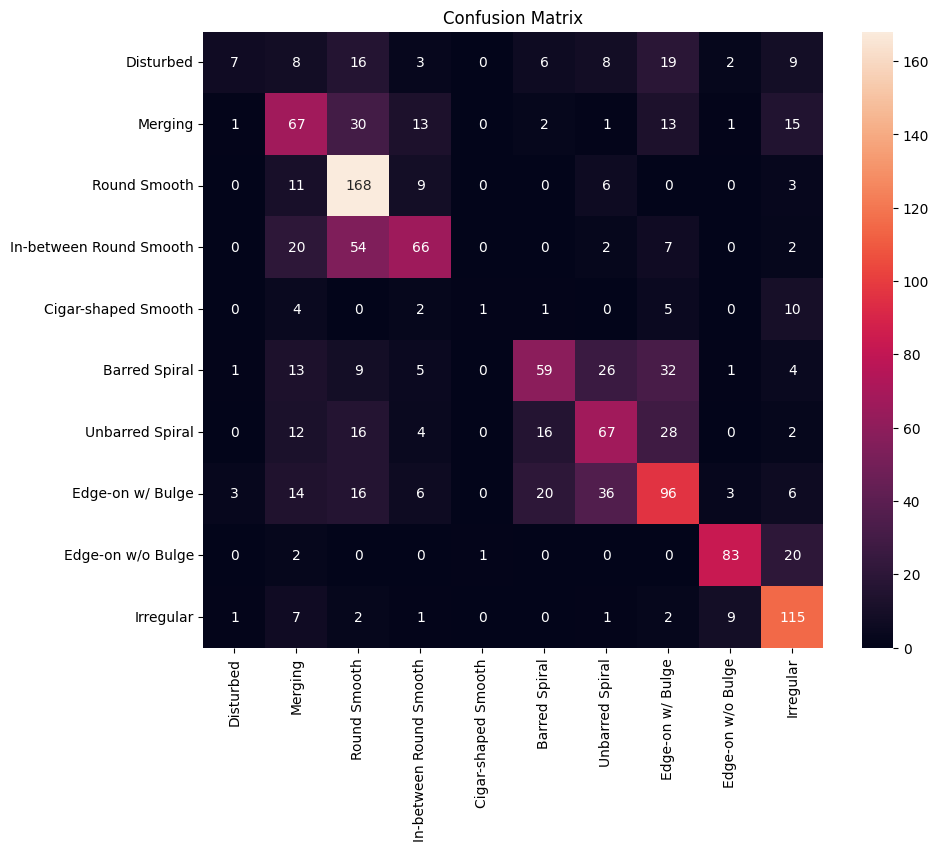

In [ ]:
# Confusion Matrix
cm_VGG16 = confusion_matrix(y_true_classes_VGG16, y_pred_classes_VGG16)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_VGG16, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.show()

## 5.2 DENSENET 201

In [ ]:
from tensorflow.keras.applications import DenseNet201 # type: ignore

num_classes = len(class_names)
img_height = images.shape[1]
img_width = images.shape[2]

# Backbone DenseNet201 pre-addestrato
densenet = DenseNet201(
    input_shape=(img_height, img_width, 3),
    weights='imagenet',
    include_top=False
)
for layer in densenet.layers:
    layer.trainable = False

# Head personalizzato
x = GlobalAveragePooling2D()(densenet.output)
x = Dense(num_classes, activation='softmax')(x)
model_DENSENET201 = Model(inputs=densenet.input, outputs=x)

model_DENSENET201.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_DENSENET201.keras', save_best_only=True)
]

# Train generatori
history_DENSENET201 = model_DENSENET201.fit(
    train_flow,
    epochs=15,
    validation_data=val_flow,
    callbacks=callbacks
)

Epoch 1/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 118s 326ms/step - accuracy: 0.3675 - loss: 1.7985 - val_accuracy: 0.4887 - val_loss: 1.4710
Epoch 2/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - accuracy: 0.5507 - loss: 1.2717 - val_accuracy: 0.5015 - val_loss: 1.3798
Epoch 3/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - accuracy: 0.5852 - loss: 1.1772 - val_accuracy: 0.5436 - val_loss: 1.3034
Epoch 4/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.6167 - loss: 1.0979 - val_accuracy: 0.5414 - val_loss: 1.2838
Epoch 5/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - accuracy: 0.6241 - loss: 1.0565 - val_accuracy: 0.5444 - val_loss: 1.2701
Epoch 6/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - accuracy: 0.6427 - loss: 1.0035 - val_accuracy: 0.5647 - val_loss: 1.2361
Epoch 7/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.6555 - loss: 0.9873 - val_accuracy: 0.5549 - val_loss: 1.2366
Epoch 8/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.6551 - loss: 0.9756 

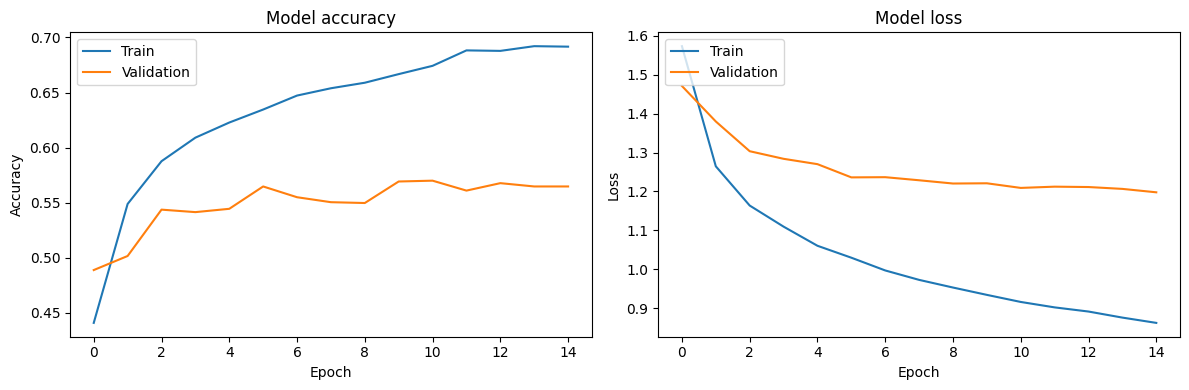

In [ ]:
# Plot accuracy and loss over epochs
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_DENSENET201.history['accuracy'])
plt.plot(history_DENSENET201.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_DENSENET201.history['loss'])
plt.plot(history_DENSENET201.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.metrics import CategoricalAccuracy

# Evaluate the model on the test set
test_loss_DENSENET201, test_acc_DENSENET201 = model_DENSENET201.evaluate(test_flow, verbose=0)
print(f'Test Accuracy: {test_acc_DENSENET201:.4f}')

# Get predictions for the test set
y_pred_DENSENET201 = model_DENSENET201.predict(test_flow)
y_pred_classes_DENSENET201 = np.argmax(y_pred_DENSENET201, axis=1)
y_true_classes_DENSENET201 = np.argmax(y_test, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_classes_DENSENET201, y_pred_classes_DENSENET201, target_names=class_names))


Test Accuracy: 0.5748
42/42 ━━━━━━━━━━━━━━━━━━━━ 42s 545ms/step

Classification Report:
                         precision    recall  f1-score   support

              Disturbed       0.32      0.19      0.24        78
                Merging       0.49      0.45      0.47       143
           Round Smooth       0.58      0.77      0.66       197
In-between Round Smooth       0.53      0.56      0.54       151
    Cigar-shaped Smooth       0.33      0.13      0.19        23
          Barred Spiral       0.52      0.61      0.56       150
        Unbarred Spiral       0.54      0.51      0.53       145
       Edge-on w/ Bulge       0.58      0.43      0.50       200
      Edge-on w/o Bulge       0.87      0.75      0.81       106
              Irregular       0.68      0.82      0.75       138

               accuracy                           0.57      1331
              macro avg       0.54      0.52      0.52      1331
           weighted avg       0.57      0.57      0.56      1331


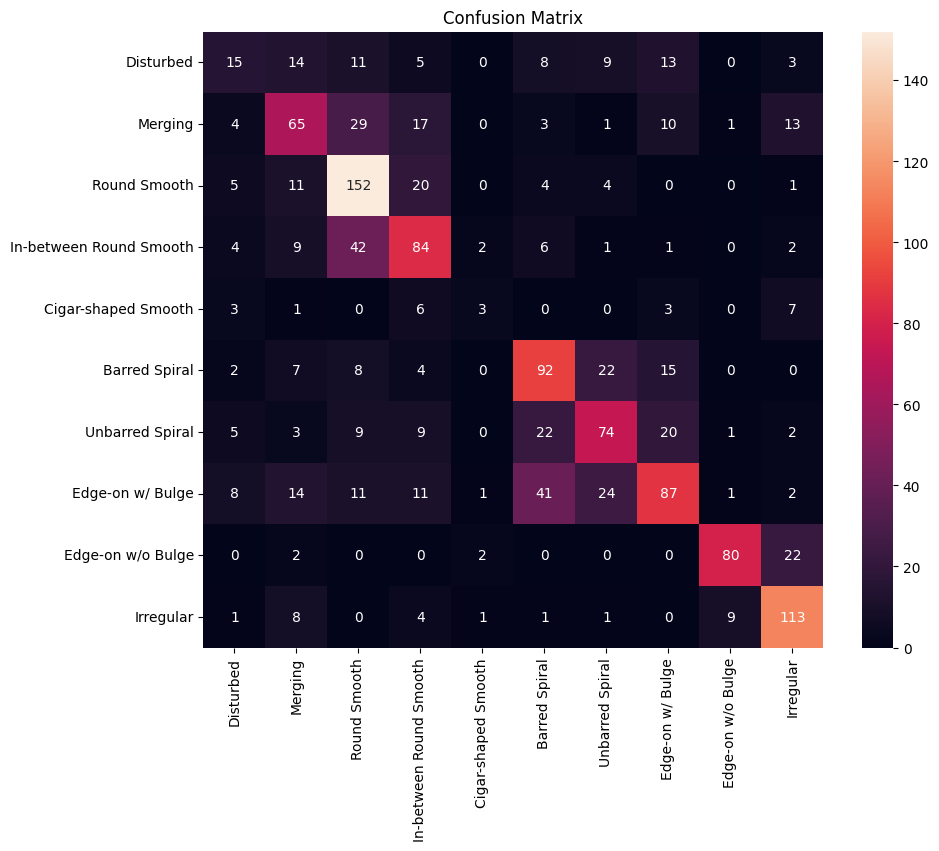

In [ ]:
# Confusion Matrix
cm_DENSENET201 = confusion_matrix(y_true_classes_DENSENET201, y_pred_classes_DENSENET201)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_DENSENET201, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.show()

In [ ]:
model_DENSENET201.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 134, 134,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 18,379,616 (70.11 MB)

 Trainable params: 19,210 (75.04 KB)

 Non-trainable params: 18,321,984 (69.89 MB)

 Optimizer params: 38,422 (150.09 KB)

## 5.3 First Custom Model

In [ ]:
from tensorflow.keras import layers, models

def build_custom_cnn(input_shape=(128, 128, 3), num_classes=10):
    inputs = layers.Input(shape=input_shape)

    # Conv Block 1
    x = layers.Conv2D(16, (3, 3), activation='tanh')(inputs)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=1)(x)

    # Conv Block 2
    x = layers.Conv2D(32, (3, 3), activation='tanh')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=1)(x)

    # Conv Block 3
    x = layers.Conv2D(64, (3, 3), activation='tanh')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=1)(x)

    # Conv Block 4
    x = layers.Conv2D(128, (3, 3), activation='tanh')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=1)(x)

    # Global Average Pooling and Output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='tanh')(x)
    output = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=output)


In [ ]:

# Build model
model_custom1 = build_custom_cnn(input_shape=(128, 128, 3), num_classes=10)

# Compile
model_custom1.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=[CategoricalAccuracy()]
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_custom1.keras', monitor='val_loss', save_best_only=True)

# Train
history_custom1 = model_custom1.fit(
    train_flow,
    validation_data=val_flow,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 35s 147ms/step - categorical_accuracy: 0.1933 - loss: 2.1963 - val_categorical_accuracy: 0.2241 - val_loss: 2.1164
Epoch 2/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - categorical_accuracy: 0.2869 - loss: 1.9511 - val_categorical_accuracy: 0.2526 - val_loss: 2.0574
Epoch 3/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - categorical_accuracy: 0.2945 - loss: 1.9047 - val_categorical_accuracy: 0.2398 - val_loss: 2.0628
Epoch 4/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step - categorical_accuracy: 0.3044 - loss: 1.8888 - val_categorical_accuracy: 0.2391 - val_loss: 2.0244
Epoch 5/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step - categorical_accuracy: 0.2981 - loss: 1.8909 - val_categorical_accuracy: 0.2211 - val_loss: 2.0678
Epoch 6/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step - categorical_accuracy: 0.3271 - loss: 1.8427 - val_categorical_accuracy: 0.2797 - val_loss: 1.9574
Epoch 7/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step - categorical_accurac

In [ ]:
model_custom1.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 125, 125, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 123, 123, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 122, 122, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 120, 120, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 119, 119, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 117, 117, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 116, 116, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,040 (1.22 MB)

 Trainable params: 106,346 (415.41 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 212,694 (830.84 KB)

Test Accuracy: 0.3125
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step

Classification Report:
                         precision    recall  f1-score   support

              Disturbed       0.00      0.00      0.00        78
                Merging       0.31      0.25      0.28       143
           Round Smooth       0.35      0.33      0.34       197
In-between Round Smooth       0.35      0.38      0.36       151
    Cigar-shaped Smooth       0.00      0.00      0.00        23
          Barred Spiral       0.32      0.17      0.23       150
        Unbarred Spiral       0.29      0.17      0.22       145
       Edge-on w/ Bulge       0.29      0.73      0.42       200
      Edge-on w/o Bulge       0.00      0.00      0.00       106
              Irregular       0.30      0.43      0.36       138

               accuracy                           0.31      1331
              macro avg       0.22      0.25      0.22      1331
           weighted avg       0.27      0.31      0.27      1331



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


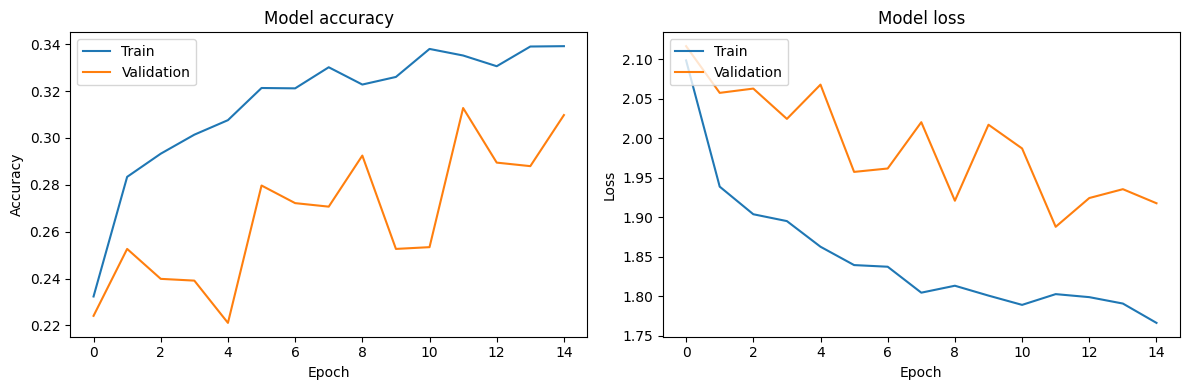

In [ ]:
# Test accuracy, classsifcation report and plot accuracy and of loss function

from tensorflow.keras.metrics import CategoricalAccuracy

# Evaluate the model on the test set
test_loss_custom1, test_acc_custom1 = model_custom1.evaluate(test_flow, verbose=0)
print(f'Test Accuracy: {test_acc_custom1:.4f}')

# Get predictions for the test set
y_pred_custom1 = model_custom1.predict(test_flow)
y_pred_classes_custom1 = np.argmax(y_pred_custom1, axis=1)
y_true_classes_custom1 = np.argmax(y_test, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_classes_custom1, y_pred_classes_custom1, target_names=class_names))

# Plot accuracy and loss over epochs
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_custom1.history['categorical_accuracy'])
plt.plot(history_custom1.history['val_categorical_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_custom1.history['loss'])
plt.plot(history_custom1.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

## 5.3 Second Custom Model

In [ ]:
from tensorflow.keras.applications import ResNet50 # type: ignore

# Numero di classi
num_classes = len(class_names)

# Caricamento del modello ResNet50 preaddestrato su ImageNet, senza top layer
resnet = ResNet50(input_shape=(128, 128, 3),
                  weights='imagenet',
                  include_top=False)

# Congelamento dei layer preaddestrati
for layer in resnet.layers:
    layer.trainable = False

# Aggiunta dei layer personalizzati
x = Flatten()(resnet.output)
x = Dense(num_classes, activation='softmax')(x)

# Creazione del modello finale
model_RESNET50 = Model(inputs=resnet.input, outputs=x)

# Compilazione del modello
model_RESNET50.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# checking the neural network architecture
model_RESNET50.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,915,402 (91.23 MB)

 Trainable params: 327,690 (1.25 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_RESNET50.keras', save_best_only=True)
]

# Addestramento
history_RESNET50 = model_RESNET50.fit(
    train_flow,
    epochs=15,
    validation_data=val_flow,
    callbacks=callbacks
)

Epoch 1/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 34s 102ms/step - accuracy: 0.3693 - loss: 1.8171 - val_accuracy: 0.4729 - val_loss: 1.5189
Epoch 2/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.6262 - loss: 1.0544 - val_accuracy: 0.4767 - val_loss: 1.5881
Epoch 3/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.6815 - loss: 0.8958 - val_accuracy: 0.5391 - val_loss: 1.3753
Epoch 4/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.7413 - loss: 0.7445 - val_accuracy: 0.5376 - val_loss: 1.4642
Epoch 5/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.7848 - loss: 0.6554 - val_accuracy: 0.5429 - val_loss: 1.4546
Epoch 6/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.8274 - loss: 0.5534 - val_accuracy: 0.5023 - val_loss: 1.5163
Epoch 7/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.8433 - loss: 0.5058 - val_accuracy: 0.5594 - val_loss: 1.4617
Epoch 8/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.8577 - loss: 0.4700 - val_ac

Test Accuracy: 0.5665
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step

Classification Report:
                         precision    recall  f1-score   support

              Disturbed       0.40      0.10      0.16        78
                Merging       0.58      0.60      0.59       143
           Round Smooth       0.59      0.78      0.67       197
In-between Round Smooth       0.52      0.75      0.62       151
    Cigar-shaped Smooth       0.24      0.43      0.31        23
          Barred Spiral       0.56      0.43      0.48       150
        Unbarred Spiral       0.59      0.36      0.45       145
       Edge-on w/ Bulge       0.44      0.48      0.46       200
      Edge-on w/o Bulge       0.73      0.92      0.81       106
              Irregular       0.83      0.53      0.65       138

               accuracy                           0.57      1331
              macro avg       0.55      0.54      0.52      1331
           weighted avg       0.57      0.57      0.55      1331



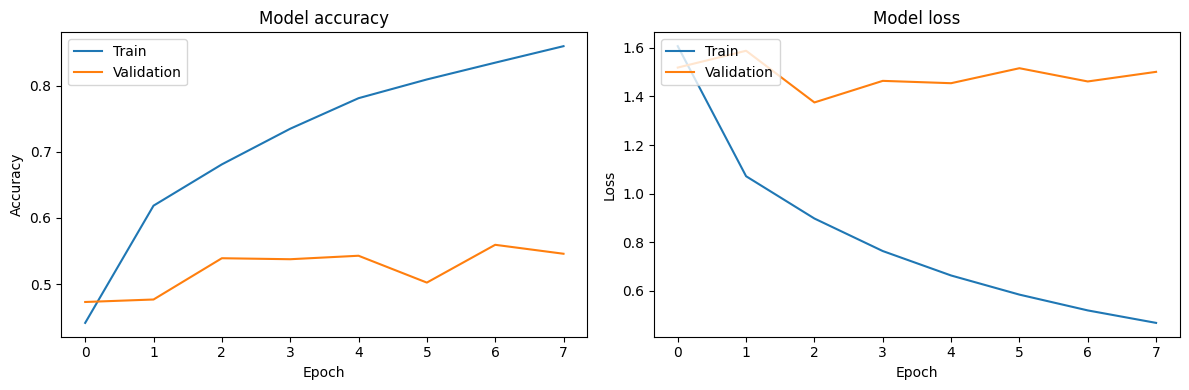

In [ ]:
# Test accuracy, classsifcation report and plot accuracy and of loss function

from tensorflow.keras.metrics import CategoricalAccuracy

# Evaluate the model on the test set
test_loss_RESNET50, test_acc_RESNET50 = model_RESNET50.evaluate(test_flow, verbose=0)
print(f'Test Accuracy: {test_acc_RESNET50:.4f}')

# Get predictions for the test set
y_pred_RESNET50 = model_RESNET50.predict(test_flow)
y_pred_classes_RESNET50 = np.argmax(y_pred_RESNET50, axis=1)
y_true_classes_RESNET50 = np.argmax(y_test, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_classes_RESNET50, y_pred_classes_RESNET50, target_names=class_names))

# Plot accuracy and loss over epochs
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_RESNET50.history['accuracy'])
plt.plot(history_RESNET50.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_RESNET50.history['loss'])
plt.plot(history_RESNET50.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

## 5.4 MOBILENETV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2

num_classes = len(class_names)
img_height = images.shape[1]
img_width = images.shape[2]

# Backbone MobileNetV2 pre-addestrato
mobilenet = MobileNetV2(
    input_shape=(img_height, img_width, 3),
    weights='imagenet',
    include_top=False
)
for layer in mobilenet.layers:
    layer.trainable = False

# Head personalizzato
x = GlobalAveragePooling2D()(mobilenet.output)
x = Dense(num_classes, activation='softmax')(x)
model_MobileNetV2 = Model(inputs=mobilenet.input, outputs=x)

model_MobileNetV2.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Addestramento con generatori
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_MobileNetV2.keras', save_best_only=True)
]

history_MobileNetV2 = model_MobileNetV2.fit(
    train_flow,
    epochs=15,
    validation_data=val_flow,
    callbacks=callbacks
)

Epoch 1/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.3089 - loss: 1.9575 - val_accuracy: 0.3917 - val_loss: 1.6142
Epoch 2/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4924 - loss: 1.3774 - val_accuracy: 0.4534 - val_loss: 1.5162
Epoch 3/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5240 - loss: 1.3005 - val_accuracy: 0.4534 - val_loss: 1.5095
Epoch 4/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5668 - loss: 1.1811 - val_accuracy: 0.4586 - val_loss: 1.5017
Epoch 5/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5790 - loss: 1.1524 - val_accuracy: 0.4639 - val_loss: 1.5121
Epoch 6/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5633 - loss: 1.1640 - val_accuracy: 0.4624 - val_loss: 1.5249
Epoch 7/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5987 - loss: 1.0887 - val_accuracy: 0.4699 - val_loss: 1.4866
Epoch 8/15
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6195 - loss: 1.0694 - val_acc

Test Accuracy: 0.4884
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step

Classification Report:
                         precision    recall  f1-score   support

              Disturbed       0.39      0.09      0.15        78
                Merging       0.34      0.38      0.36       143
           Round Smooth       0.49      0.79      0.60       197
In-between Round Smooth       0.60      0.26      0.37       151
    Cigar-shaped Smooth       0.60      0.26      0.36        23
          Barred Spiral       0.49      0.24      0.32       150
        Unbarred Spiral       0.41      0.42      0.42       145
       Edge-on w/ Bulge       0.40      0.55      0.46       200
      Edge-on w/o Bulge       0.75      0.80      0.77       106
              Irregular       0.65      0.70      0.67       138

               accuracy                           0.49      1331
              macro avg       0.51      0.45      0.45      1331
           weighted avg       0.50      0.49      0.47      1331



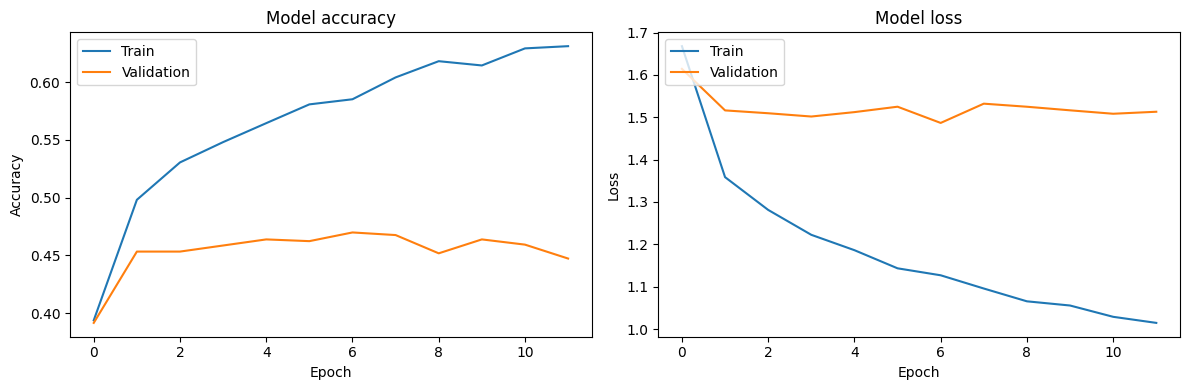

In [ ]:
# Test accuracy, classsifcation report and plot accuracy and of loss function

from tensorflow.keras.metrics import CategoricalAccuracy

# Evaluate the model on the test set
test_loss_MobileNetV2, test_acc_MobileNetV2 = model_MobileNetV2.evaluate(test_flow, verbose=0)
print(f'Test Accuracy: {test_acc_MobileNetV2:.4f}')

# Get predictions for the test set
y_pred_MobileNetV2 = model_MobileNetV2.predict(test_flow)
y_pred_classes_MobileNetV2 = np.argmax(y_pred_MobileNetV2, axis=1)
y_true_classes_MobileNetV2 = np.argmax(y_test, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_classes_MobileNetV2, y_pred_classes_MobileNetV2, target_names=class_names))

# Plot accuracy and loss over epochs
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_MobileNetV2.history['accuracy'])
plt.plot(history_MobileNetV2.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_MobileNetV2.history['loss'])
plt.plot(history_MobileNetV2.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

## 6. Employment of GRADCAM

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Immagine 1
True Class: Disturbed
Predicted Class: Round Smooth (Confidence: 0.2998)


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 128, 128, 3))


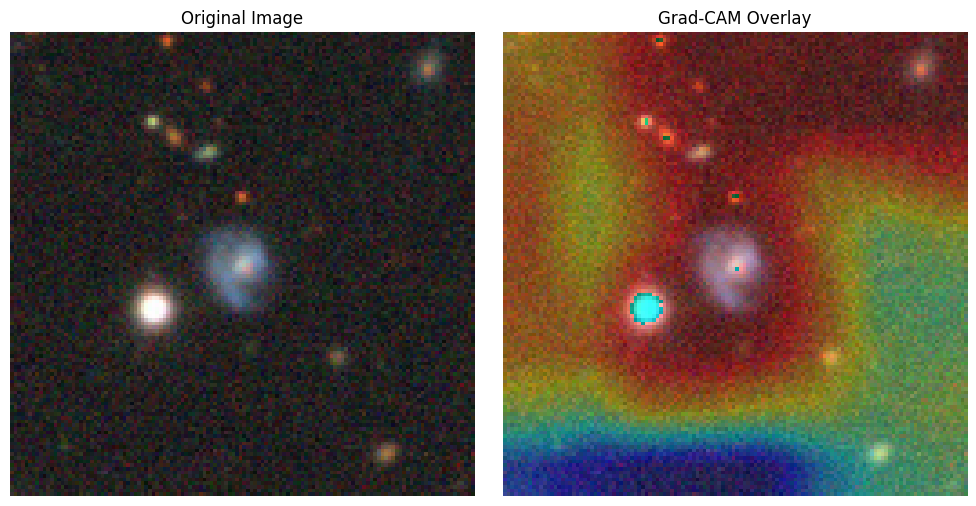

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Immagine 2
True Class: Irregular
Predicted Class: Round Smooth (Confidence: 0.3075)


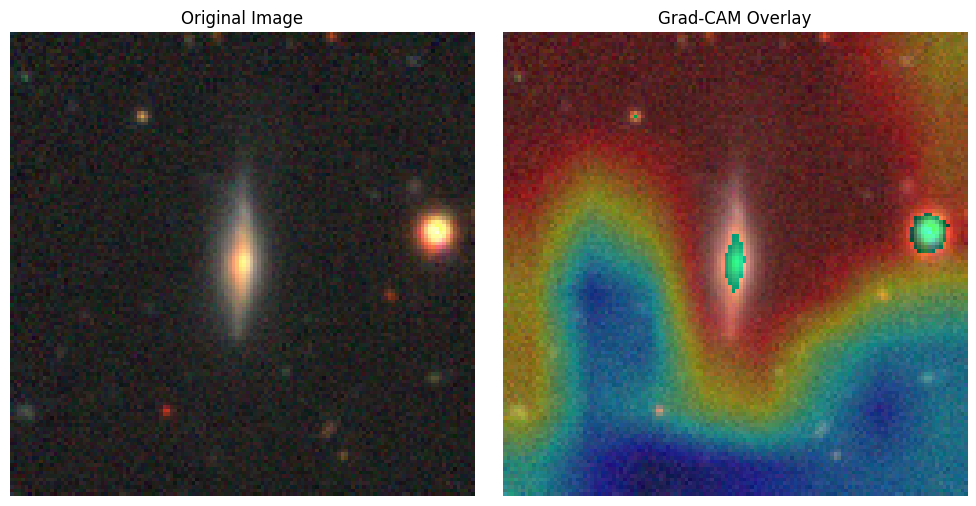

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Immagine 3
True Class: Merging
Predicted Class: Round Smooth (Confidence: 0.2922)


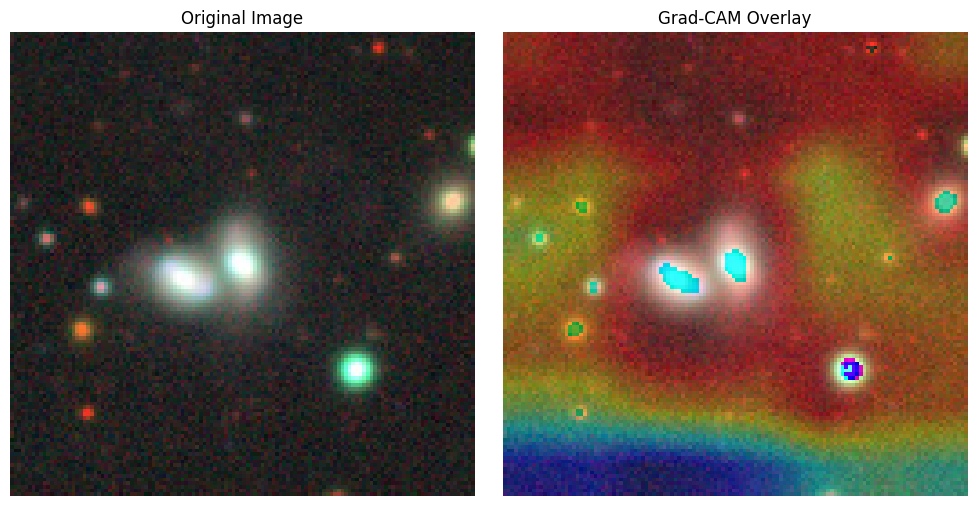

In [ ]:
## VGG16

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def save_and_display_gradcam(img, heatmap, alpha=0.4):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = heatmap_colored * alpha + img
    superimposed_img = np.uint8(superimposed_img)
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title('Grad-CAM Overlay')

# --- Grad-CAM Implementation ---

# 1. Seleziona 3 immagini random dal test set
idxs = random.sample(range(len(X_test_norm)), 3)
selected_imgs = X_test_norm[idxs]
selected_labels = np.argmax(y_test[idxs], axis=1)

# 2. Nome dell'ultimo layer convoluzionale di VGG16
last_conv_layer_name = "block5_conv3"

# 3. Grad-CAM per ciascuna immagine
for i in range(3):
    img_array = np.expand_dims(selected_imgs[i], axis=0)
    # VGG16 vuole immagini in [0,255] in RGB, ma qui sono già normalizzate: moltiplica per 255 se serve
    img_for_display = (selected_imgs[i] * 255).astype(np.uint8)
    img_for_display_bgr = cv2.cvtColor(img_for_display, cv2.COLOR_RGB2BGR)

    preds = model_VGG16.predict(img_array)
    predicted_class_index = np.argmax(preds[0])
    true_class_index = selected_labels[i]

    print(f"Immagine {i+1}")
    print(f"True Class: {class_names[true_class_index]}")
    print(f"Predicted Class: {class_names[predicted_class_index]} (Confidence: {preds[0][predicted_class_index]:.4f})")

    heatmap = make_gradcam_heatmap(img_array, model_VGG16, last_conv_layer_name, pred_index=predicted_class_index)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_for_display)
    plt.axis('off')
    plt.title('Original Image')

    plt.subplot(1, 2, 2)
    save_and_display_gradcam(img_for_display_bgr, heatmap, alpha=0.4)
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step
Immagine 1
True Class: Cigar-shaped Smooth
Predicted Class: Cigar-shaped Smooth (Confidence: 0.2515)


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_21']
Received: inputs=Tensor(shape=(1, 128, 128, 3))


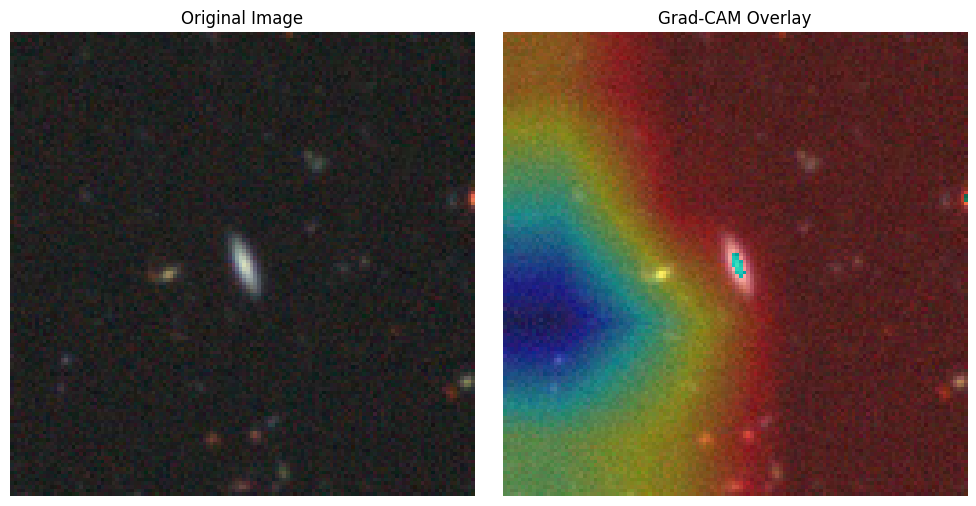

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Immagine 2
True Class: Round Smooth
Predicted Class: Round Smooth (Confidence: 0.7416)


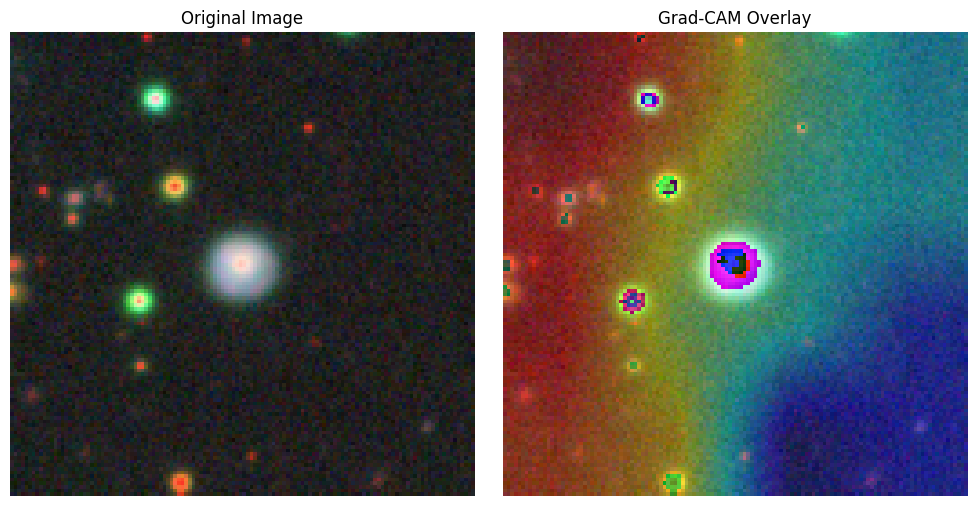

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Immagine 3
True Class: Irregular
Predicted Class: Irregular (Confidence: 0.3749)


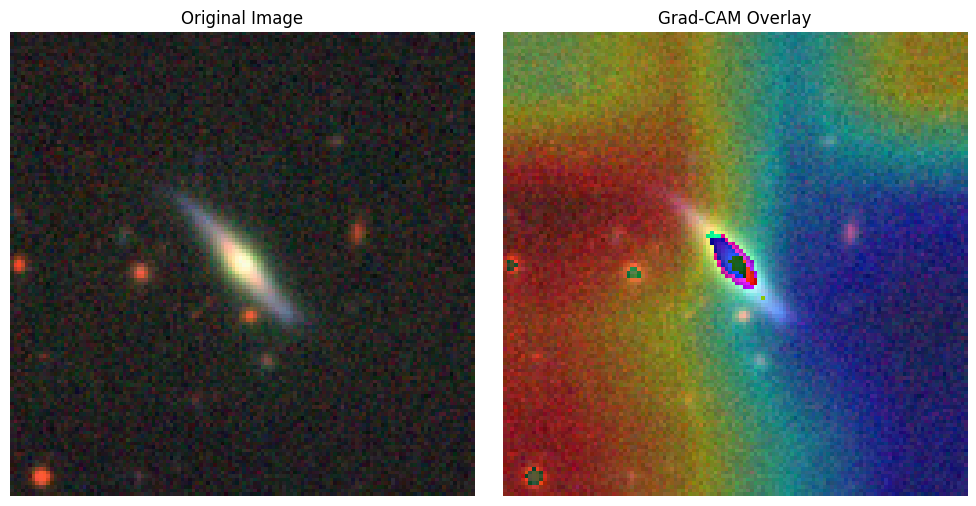

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import cv2
import random
import os

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def save_and_display_gradcam(img, heatmap, alpha=0.4):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = heatmap_colored * alpha + img
    superimposed_img = np.uint8(superimposed_img)
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title('Grad-CAM Overlay')

# --- Grad-CAM Implementation ---

# 1. Seleziona 3 immagini random dal test set
idxs = random.sample(range(len(X_test_norm)), 3)
selected_imgs = X_test_norm[idxs]
selected_labels = np.argmax(y_test[idxs], axis=1)

# 2. Nome dell'ultimo layer convoluzionale di DenseNet201
last_conv_layer_name = "conv5_block32_concat"  # Verifica con model_DENSENET201.summary() se usi una versione modificata

# 3. Grad-CAM per ciascuna immagine
for i in range(3):
    img_array = np.expand_dims(selected_imgs[i], axis=0)
    # DenseNet201 vuole immagini in [0,255] in RGB, ma qui sono già normalizzate: moltiplica per 255 se serve
    img_for_display = (selected_imgs[i] * 255).astype(np.uint8)
    img_for_display_bgr = cv2.cvtColor(img_for_display, cv2.COLOR_RGB2BGR)

    preds = model_DENSENET201.predict(img_array)
    predicted_class_index = np.argmax(preds[0])
    true_class_index = selected_labels[i]

    print(f"Immagine {i+1}")
    print(f"True Class: {class_names[true_class_index]}")
    print(f"Predicted Class: {class_names[predicted_class_index]} (Confidence: {preds[0][predicted_class_index]:.4f})")

    heatmap = make_gradcam_heatmap(img_array, model_DENSENET201, last_conv_layer_name, pred_index=predicted_class_index)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_for_display)
    plt.axis('off')
    plt.title('Original Image')

    plt.subplot(1, 2, 2)
    save_and_display_gradcam(img_for_display_bgr, heatmap, alpha=0.4)
    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Immagine 1
True Class: Disturbed
Predicted Class: Merging (Confidence: 0.5352)


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_946']
Received: inputs=Tensor(shape=(1, 128, 128, 3))


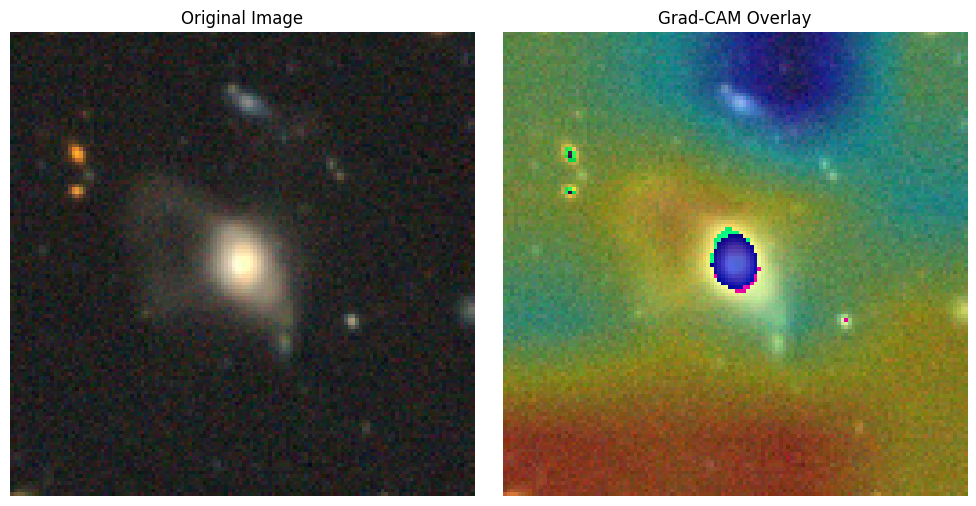

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Immagine 2
True Class: Barred Spiral
Predicted Class: Irregular (Confidence: 0.8161)


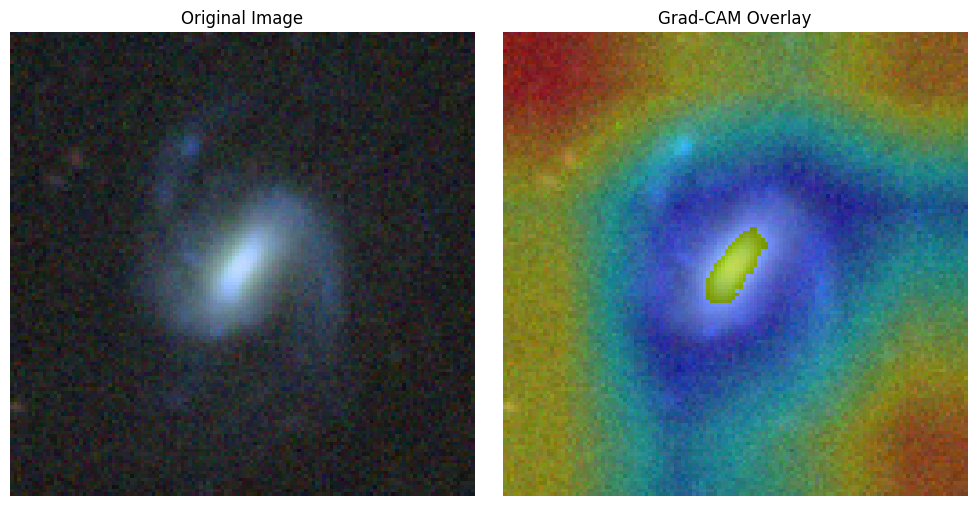

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Immagine 3
True Class: Disturbed
Predicted Class: Merging (Confidence: 0.4905)


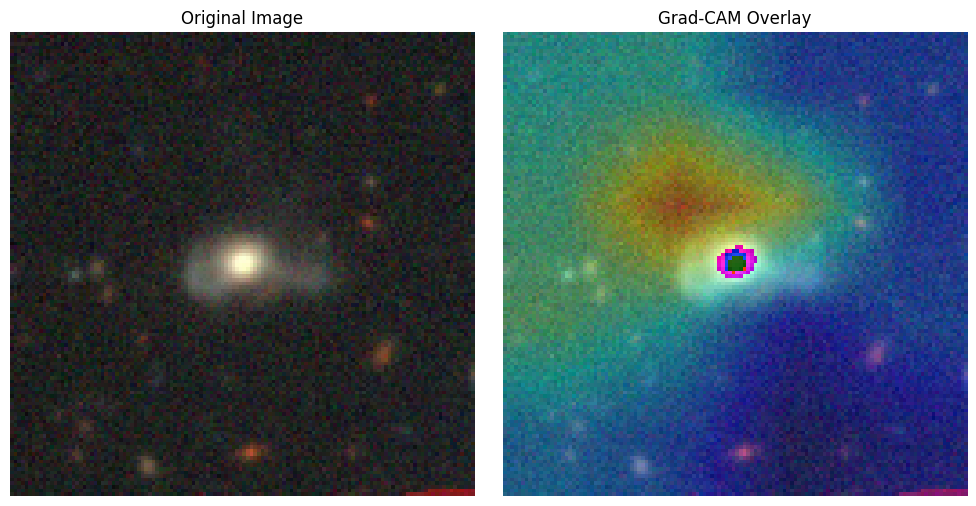

In [ ]:
## MOBILENET

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def save_and_display_gradcam(img, heatmap, alpha=0.4):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = heatmap_colored * alpha + img
    superimposed_img = np.uint8(superimposed_img)
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title('Grad-CAM Overlay')

# --- Grad-CAM Implementation ---

# 1. Seleziona 3 immagini random dal test set
idxs = random.sample(range(len(X_test_norm)), 3)
selected_imgs = X_test_norm[idxs]
selected_labels = np.argmax(y_test[idxs], axis=1)

# 2. Nome dell'ultimo layer convoluzionale di MobileNetV2
last_conv_layer_name = "Conv_1"  # Cambia questo se il tuo modello personalizzato ha un altro nome per l'ultimo conv layer

# 3. Grad-CAM per ciascuna immagine
for i in range(3):
    img_array = np.expand_dims(selected_imgs[i], axis=0)
    # MobileNetV2 vuole immagini in [0,255] in RGB, ma qui sono già normalizzate: moltiplica per 255 se serve
    img_for_display = (selected_imgs[i] * 255).astype(np.uint8)
    img_for_display_bgr = cv2.cvtColor(img_for_display, cv2.COLOR_RGB2BGR)

    preds = model_MobileNetV2.predict(img_array)
    predicted_class_index = np.argmax(preds[0])
    true_class_index = selected_labels[i]

    print(f"Immagine {i+1}")
    print(f"True Class: {class_names[true_class_index]}")
    print(f"Predicted Class: {class_names[predicted_class_index]} (Confidence: {preds[0][predicted_class_index]:.4f})")

    heatmap = make_gradcam_heatmap(img_array, model_MobileNetV2, last_conv_layer_name, pred_index=predicted_class_index)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_for_display)
    plt.axis('off')
    plt.title('Original Image')

    plt.subplot(1, 2, 2)
    save_and_display_gradcam(img_for_display_bgr, heatmap, alpha=0.4)
    plt.tight_layout()
    plt.show()
